In [1]:
import numpy as np
from skimage import io, feature, color, draw, util, measure
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path
# import sys
# sys.path.append(r'C:\Users\jglic\Documents\School\WashU\Mukherji Lab\organelle-measure\organelle_measure')
# from cell_cycle import cc_sort

## To add:
1. ~~Ignore rois that touch the image boundary If this doesn't solve the large number of 1-2 point unique rois in photobleaching analysis, then address that by decreasing overlap requirement?~~ DONE-ish
1. ~~Exponential fitting function.~~ DONE
1. ~~Apply exponential fitting function to myo1 photobleaching curves and plot distribution of decay parameters.~~ DONE
1. ~~Anayze fitting parameter distributions and apply correction.~~
1. Overlay mother & bud A(t) curves onto their corresponding myo1 signal timelapses.
1. Reprocess all datasets with updated params (as of 2/6/26)

In [2]:
# cc_sort(r'C:\Users\jglic\Downloads\11-5-25 myo1-mLemon\Run_2\BF-timelapse_acdc_output_cpsam-d10-ms8.csv')

In [3]:
def exp_fnc(x: float, a: float, b: float, c: float):
    """
    Args: Four paramters consisting of an independent variable (x) and three fitting params (a,b,c).
    Ouputs: A float value from plugging all of the variables into a generic exponential function form. 
    """
    return a * np.exp(-b * x) + c

In [4]:
def detect_globular_rois(img_or_path, frame_index=0,
                         min_sigma=1, max_sigma=3, num_sigma=10,
                         threshold=0.2, overlap=0.5,
                         roi_radius=5, return_overlay=True):
    """
    Detect globular signals, draw circular ROIs around their centroids, and compute the sum intensity of pixels within.

    Args:
      img_or_path: 2D numpy array or path to a TIF (can be a stack but channel order must be in txy or tyx).
      frame_index: if img_or_path is a stack, index of frame to analyze.
      min_sigma, max_sigma, num_sigma, threshold, overlap: skimage.blob_log params.
      roi_radius: if None, radius = sqrt(2)*sigma for each blob; otherwise fixed radius in pixels.
      return_overlay: if True, also return an RGB image with circular ROI outlines.
    Returns:
      results: dataframe from list of dicts: {'y':..., 'x':..., 'radius':..., 'sum':...}
      overlay (optional): RGB image (uint8) with red ROI outlines overlaid on the analyzed frame.
    """
    if isinstance(img_or_path, (str, bytes)):
        img = io.imread(img_or_path) #file path
    else:
        img = np.asarray(img_or_path) #image matrix

    #If image is a stack (time lapse), work only on the designated frame.
    if img.ndim == 3:
        img2d = img[frame_index,:,:] #(t,y,x) or (t,x,y) channel order.
    elif img.ndim == 2:
        img2d = img
    else:
        raise ValueError("Image must be 2D or 3D stack")

    #Normalize image pixel values
    # img_f = util.img_as_float(img2d)/np.max(img2d)
    img_f=img2d

    #Detect blobs using Laplacian of Gaussian.
    #Returns an array with the centroid coords of each detected blob plus the sigma of each blob.
    blobs = feature.blob_log(img_f, min_sigma=min_sigma, max_sigma=max_sigma,
                             num_sigma=num_sigma, threshold_rel=threshold, overlap=overlap)
    results = [] #initialize results list
    #Generate overlay variable
    overlay = None
    if return_overlay==True:
        rgb = color.gray2rgb(util.img_as_ubyte(img_f/np.max(img_f)))
        overlay = rgb.copy()

    roi_ind=0#generate ROI index to distinguish unique ROIs
    #and then plot the ROIs for each detected blob
    for y, x, sigma in blobs: #for each detected blob in this frame...
        r = (np.sqrt(2) * sigma) if roi_radius is None else roi_radius #compute radius if none is set, otherwise use given value.
        r_int = int(max(1, round(r))) #radius must be an integer value of pixels greater than or equal to one. 

        if (y-r)<0 or (y+r)>img_f.shape[1] or (x-r)<0 or (x+r)>img_f.shape[0]: #exclude those rois touching the image boundary
            continue
        else:
            rr, cc = draw.disk((y, x), r_int, shape=img_f.shape) #generate a disk mask about each given centroid.
            sum_intensity = float(img_f[rr, cc].sum()) #sum all pixel intensities within said disk.
            avg_intensity = sum_intensity/(img_f.shape[0]*img_f.shape[1])
            results.append({'ROI_ID': roi_ind,'frame':frame_index,'y': float(y), 'x': float(x), 'radius': float(r), 'sum': sum_intensity, 'avg': avg_intensity}) #append the summed intensity and other relevant metrics to the results dictionary.
            if return_overlay: 
                pr, pc = draw.circle_perimeter(int(round(y)), int(round(x)), r_int, shape=overlay.shape[:2]) #draw the circular ROIs around the glob centroids.
                overlay[pr, pc] = (255, 255, 0) #sets color of ROI circles using RGB values.
            roi_ind+=1 #update ROI index
    if return_overlay==True: 
        io.imshow(overlay)
    return pd.DataFrame.from_dict(results)


In [ ]:
def roi_overlap(x1,y1,x2,y2, roi_radius: int, shape: tuple): 
    """
    Args: Two sets of x-y centroid coords, roi radius paramter.
    Outputs: Fractional overlap between disks of equal radius centered about each centroid given.
    """

    if np.absolute(x1-x2)>(2*roi_radius) or np.absolute(y1-y2)>(2*roi_radius): #If overlap impossible, don't bother.
        frac_olap=0
    else: #otherwise, do the overlap calculation
        rr1, cc1 = draw.disk((y1, x1), roi_radius, shape=shape) #generate a disk mask about first centroid; variables contain pixel coords.
        dummy1=np.ones(shape) #dummy array for overlap measure
        dummy1[rr1,cc1]=-1 #set ROI pixel values to -1
        mask1=dummy1<0 #Apply Boolean statement such that ROI pixels become Trues and all else become Falses.
        rr2, cc2 = draw.disk((y2, x2), roi_radius, shape=shape) #generate a disk mask about second centroid; variables contain pixel coords.
        dummy2=np.ones(shape) #dummy array for overlap measure
        dummy2[rr2,cc2]=-1 #set ROI pixel values to -1
        mask2=dummy2<0 #Apply Boolean statement such that ROI pixels become Trues and all else become Falses.
        frac_olap=measure.intersection_coeff(mask1, mask2) #measure fractional overlap of Boolean ROI masks.
    return frac_olap

def analyze_budnecks(img_or_path: str or numpy.ndarray,  roi_radius: int, olap_thresh: float=0.5, frame_buffer: int=3, sweep_radius: int=16):
    """
    Args: Image matrix or path to image file, threshold for sufficient fractional overlap, number of frames for buffer on either end of detected time region
    Outputs: Dataframe consisting of roi id, frame number, x-y centroid coords, roi radius, and sum pixel intensity w/in roi
    for each detected globular signal within each frame of time lapse. 
    """
    
    if isinstance(img_or_path, (str, bytes)):
        img_f = io.imread(img_or_path) #file path
    else:
        img_f = np.asarray(img_or_path) #image matrix
    shape=(img_f.shape[1],img_f.shape[2])
    
    for frame_i in range(img_f.shape[0]): #for each frame in timelapse...
        print('processing frame '+str(frame_i)+'/'+str(np.max(img_f.shape[0])-1)) #optional frame by frame progress update
        if frame_i==0: #for first frame, run initial globular detection and record ROIs and other metrics.
            running_list=detect_globular_rois(img_f, frame_index=frame_i, roi_radius=roi_radius, return_overlay=False) #dataframe containing metrics for frame_0
        else: #for each frame past the first...
            cand_globs=detect_globular_rois(img_f, frame_index=frame_i, roi_radius=roi_radius, return_overlay=False) #detect signal candidates in new frame.
            no_overlap_idxs=[]
            established_ids=list(np.unique(running_list['ROI_ID'].values))
            
            for cand_idx in cand_globs.index: #for each candidate new roi...
                candx, candy = cand_globs.iloc[cand_idx]['x'], cand_globs.iloc[cand_idx]['y'] #extract centroid coords of candidate ROI
                overlap_ids, overlaps=[],[] #initialize lists for overlap comparison

                for estb_id in established_ids: #for each preexisting ROI...
                    estb_mask=running_list['ROI_ID'].values==estb_id #generate mask of its dataframe row
                    if frame_i-running_list[estb_mask]['frame'].values[-1]<=1: #if is with recent-enough roi...
                        estbx, estby = running_list[estb_mask]['x'].values[-1], running_list[estb_mask]['y'].values[-1] #extract most recent centroid coords of established ROI
                        if (candx-estbx)**2 + (candy-estby)**2 < (2*roi_radius)**2: #if the centroids are in the same neighborhood
                            overlap=roi_overlap(candx,candy,estbx,estby,roi_radius,shape) #calculate fractional overlap between candidate roi and each previous one.
                            if overlap>=olap_thresh: #if overlap has sufficient fraction...
                                overlap_ids.append(estb_id)
                                overlaps.append(overlap)
                        # else: #otherwise, move along through the rest of the established rois.
                        #     continue #move along, move along like i know ya do. move along, move along just to make it through
                if len(overlap_ids)>0: #if at least one overlap option
                    new_id=overlap_ids[overlaps.index(np.max(overlaps))] 
                    cand_globs.loc[cand_globs.index==cand_idx, 'ROI_ID']=new_id #reassign candidate roi_id to that of established roi with max overlap
                    established_ids.remove(new_id)
                else:
                    no_overlap_idxs.append(cand_idx) #record candidates and estbs that don't meet the overlap threshold.

            id_ind=1 #reset dummy id index value to use when assigning new, unique roi_ids to new signals.
            for cand_idx in no_overlap_idxs:
                candx, candy = cand_globs.iloc[cand_idx]['x'], cand_globs.iloc[cand_idx]['y'] #extract centroid coords of candidate ROI
                neighbor_ids, dists=[],[]
                for estb_id in established_ids: #for each unmatched/available preexisting ROI...
                    estb_mask=running_list['ROI_ID'].values==estb_id
                    if frame_i-running_list[estb_mask]['frame'].values[-1]<=1: #if is recent-enough roi...
                        estbx, estby = running_list[estb_mask]['x'].values[-1], running_list[estb_mask]['y'].values[-1] #extract most recent centroid coords of established ROI
                        if dist:=((candx-estbx)**2 + (candy-estby)**2) < (sweep_radius)**2: #if the centroids are in the same neighborhood
                            neighbor_ids.append(estb_id)
                            dists.append(dist)
                if len(neighbor_ids)>0: #if at least one neighbor option
                    new_id=neighbor_ids[dists.index(np.min(dists))] 
                    # print('assign '+str(new_id))
                    cand_globs.loc[cand_globs.index==cand_idx, 'ROI_ID']=new_id #reassign candidate roi_id to that of established roi with max overlap
                    established_ids.remove(new_id)
                
                else: #if insufficient dist to preexisting signals...
                    new_id=(np.max(running_list['ROI_ID'].values)+id_ind)
                    # print('new '+str(new_id))
                    cand_globs.loc[cand_globs.index==cand_idx, 'ROI_ID']=new_id #assign new id to accepted source
                    id_ind+=1 #update dummy id index to reflect new signal recognized.
                
            running_list=pd.concat([running_list,cand_globs], ignore_index=True) #append this frame's information to running dataframe.
    
    #When possible, add frame buffer to either end of detected region.
    buffer_dicts=[]          
    r_int = int(max(1, round(roi_radius))) #radius must be an integer value of pixels greater than or equal to one.
    unique_rois=np.unique(running_list['ROI_ID'].values) 
    for roi_id in unique_rois: #for each unique roi detected...
        print('processing buffer frames for '+str(roi_id)+'/'+str(np.max(unique_rois))) #optional frame by frame progress update
        roi_slice=running_list[running_list['ROI_ID']==roi_id]
        first_frame,last_frame=roi_slice['frame'].values[0],roi_slice['frame'].values[-1]
        
        if first_frame>0:
            x,y=roi_slice.loc[roi_slice.frame==first_frame,'x'].values[0], roi_slice.loc[roi_slice.frame==first_frame,'y'].values[0]
            
            for frame_offset in np.arange(1,frame_buffer+1): #for each buffer frame asked for...
                
                if (first_frame-frame_offset)>=0: #if the frame exists to measure, then measure using roi from first_frame.
                    rr, cc = draw.disk((y, x), r_int, shape=(img_f.shape[1],img_f.shape[2])) #generate a disk mask about each given centroid.
                    sum_intensity = float(img_f[first_frame-frame_offset,rr, cc].sum()) #sum all pixel intensities within said disk.
                    avg_intensity = sum_intensity/(len(rr)*len(cc))
                    buffer_dicts.append({'ROI_ID': roi_id,'frame':(first_frame-frame_offset),'y': float(y), 'x': float(x), 'radius': float(roi_radius), 'sum': sum_intensity, 'avg': avg_intensity}) #append the summed intensity and other relevant metrics to the results dictionary.
      
        if last_frame<(img_f.shape[0]-1): #if last frame before the end of time lapse...
            x,y=roi_slice.loc[roi_slice.frame==last_frame,'x'].values[-1], roi_slice.loc[roi_slice.frame==last_frame,'y'].values[-1]
            
            for frame_offset in np.arange(1,frame_buffer+1): #for each buffer frame asked for...
                
                if (last_frame+frame_offset)<=(img_f.shape[0]-1): #if the frame exists to measure, then measure using roi from last_frame.
                    rr, cc = draw.disk((y, x), r_int, shape=(img_f.shape[1],img_f.shape[2])) #generate a disk mask about each given centroid.
                    sum_intensity = float(img_f[last_frame+frame_offset,rr, cc].sum()) #sum all pixel intensities within said disk.
                    avg_intensity = sum_intensity/(len(rr)*len(cc))
                    buffer_dicts.append({'ROI_ID': roi_id,'frame':(last_frame+frame_offset),'y': float(y), 'x': float(x), 'radius': float(roi_radius), 'sum': sum_intensity, 'avg': avg_intensity}) #append the summed intensity and other relevant metrics to the results dictionary.
    buffer_df=pd.DataFrame.from_dict(buffer_dicts)
    output_df=pd.concat([running_list,buffer_df], ignore_index=True) #append buffer frame info to initial detection analysis.  
    output_df=output_df.sort_values(by=['frame'])
    return output_df


In [ ]:
def plot_signal(df, roi_ind, metric, plot_graph=False):
    """
    Args: Dataframe (or its corresponding file path) containing at least roi ids, frame numbers, and desired metric(s) to plot. Optional Boolean arg to generate plot.
    Outputs: Dataframe containing same info as input. Optional plot.
    """
    if plot_graph==True:
        plt.figure()
        for roi in np.unique(df['ROI_ID'].values)[roi_ind:roi_ind+1]: #for each detected roi in entire time lapse...
            mask=df['ROI_ID'].values==roi #create a mask to extract roi's rows
            roi_subset=df[mask] #apply mask
            plt.plot(roi_subset['frame'].values,roi_subset[metric].values/np.max(roi_subset[metric].values)) #plots desired metric as function of frame (proxy for time)
            plt.scatter(roi_subset['frame'].values,roi_subset[metric].values/np.max(roi_subset[metric].values), label='Roi_'+str(roi))
        plt.xlabel('Time (min)')
        plt.xlim(0,np.max(df['frame'].values)) #fix x and y bounds to whole range of values
        plt.ylim(0,1)
        # plt.ylabel('Normalized Sum Interior Pixel Intensity (AU)')
    return df

def roi_paths(df: pd.DataFrame, roi_id, roi_radius: int, img_shape: int=2048):
    """
    Args: Dataframe containing the (x,y) coords of roi(s) to visualize for each frame detected, ID of roi to display, radius of roi disk. 
    Outputs: Plot/image depicting the path of roi centroids and/or disks in coordinate space. 
    """
    id_mask=df['ROI_ID'].values==roi_id #generate mask for rows with roi_id matching that of argument
    rx, ry = df[id_mask]['x'].values, df[id_mask]['y'].values #extract centroid coords of candidate ROI
    ax.scatter(rx, ry, label='ROI Centroids')
    ax.set_xlim(0,img_shape)
    ax.set_ylim(0,img_shape)
    ax.annotate(str(roi_id), (rx[-1], ry[-1]),fontsize='x-small')
    ax.yaxis.set_inverted(True)


In [12]:
ti=io.imread(r'C:\Users\jglic\Downloads\11-5-25 myo1-mLemon\Run_2\eyrbow-yellowconfocal_zstack-avg-proj_myo1_fov2_upscaled.tif')
# ti=io.imread(r'C:\Users\jglic\Downloads\1-22-26 myo1-mLemon\SUM_yellowconf-216nm_01222026_myo1_glucose-2.0_fov1.tif')

In [13]:
# blobs = feature.blob_log(ti, min_sigma=1, max_sigma=3,num_sigma=10, threshold=0.2, overlap=0.5)

In [14]:
# tdf=detect_globular_rois(ti,min_sigma=1,max_sigma=3, roi_radius=8)

In [15]:
len(np.unique(tdf['ROI_ID'].values))

NameError: name 'tdf' is not defined

In [47]:
novrun=analyze_budnecks(r'C:\Users\jglic\Downloads\11-5-25 myo1-mLemon\Run_2\eyrbow-yellowconfocal_zstack-avg-proj_myo1_fov2_upscaled.tif',roi_radius=8)
# janrun,tb=analyze_budnecks(r'C:\Users\jglic\Downloads\Run_2\SUM_20251212_yfp-216nm_Run-2.tif')
# janrun,tb=analyze_budnecks(r'C:\Users\jglic\Downloads\1-29-26 myo1-mLemon photobleaching\SUM_20260129_131049_173__ChannelEYFPpH 7_Seq0000.tif')
# janrun,tb=analyze_budnecks(r'C:\Users\jglic\Downloads\1-29-26 myo1-mLemon photobleaching\SUM_20260129_132732_869__ChannelEYFPpH 7_Seq0000.tif')

processing frame 0/11
processing frame 1/11
assign 25
assign 61
assign 32
assign 164
assign 158
assign 93
assign 154
assign 135
assign 120
new 259
assign 160
assign 148
new 260
new 261
assign 230
new 262
assign 150
new 263
assign 190
assign 203
new 264
assign 245
new 265
new 266
new 267
new 268
new 269
new 270
new 271
new 272
new 273
new 274
new 275
new 276
processing frame 2/11
assign 32
assign 249
assign 86
assign 63
assign 120
assign 93
assign 228
assign 142
assign 205
new 277
assign 160
new 278
assign 207
assign 222
new 279
new 280
new 281
assign 235
assign 247
new 282
new 283
assign 246
new 284
new 285
new 286
new 287
new 288
new 289
new 290
new 291
new 292
new 293
new 294
new 295
new 296
new 297
new 298
new 299
new 300
processing frame 3/11
assign 277
assign 188
new 301
new 302
assign 120
new 303
assign 172
assign 260
assign 219
assign 228
assign 153
new 304
new 305
assign 116
assign 170
assign 283
assign 154
assign 230
assign 246
new 306
new 307
new 308
assign 273
new 309
new 31

In [48]:
novrun.to_csv(r'C:\Users\jglic\Downloads\11-5-25 myo1-mLemon\Run_2\eyrbow-yellowconfocal_zstack-avg-proj_myo1_fov2_upscaled.csv', index=False)
# janrun.to_csv(r'C:\Users\jglic\Downloads\1-22-26 myo1-mLemon\signal-analysis_01222026.csv', index=False)
# janrun.to_csv(r'C:\Users\jglic\Downloads\Run_2\signal-analysis_12122025.csv', index=False)
# janrun.to_csv(r'C:\Users\jglic\Downloads\1-29-26 myo1-mLemon photobleaching\signal-analysis_01292026_Run-1.csv',index=False)

In [49]:
novdf=pd.read_csv(r'C:\Users\jglic\Downloads\11-5-25 myo1-mLemon\Run_2\eyrbow-yellowconfocal_zstack-avg-proj_myo1_fov2_upscaled.csv')
# df_12122025=pd.read_csv(r'C:\Users\jglic\Downloads\Run_2\signal-analysis_12122025.csv')
# df_01222026=pd.read_csv(r'C:\Users\jglic\Downloads\1-22-26 myo1-mLemon\signal-analysis_01222026.csv')
# df_01292026_r1=pd.read_csv(r'C:\Users\jglic\Downloads\1-29-26 myo1-mLemon photobleaching\signal-analysis_01292026_Run-1.csv')
# df_01292026_r2=pd.read_csv(r'C:\Users\jglic\Downloads\1-29-26 myo1-mLemon photobleaching\signal-analysis_01292026_Run-2.csv')

In [51]:
# novdf.loc[novdf.ROI_ID==5]

In [52]:
def overlay_roi(img_or_path: str or np.ndarray, roi_df: pd.DataFrame, roi_ids: list, roi_radius: int=3, frame_index: int=0):
    """
    Args: Image or path to it, df containing extracted roi info, list of rois to overlay, kwargs.
    Outputs: Overlay of rois on image.
    """
    if isinstance(img_or_path, (str, bytes)):
        img = io.imread(img_or_path) #file path
    else:
        img = np.asarray(img_or_path) #image matrix

    #If image is a stack (time lapse), work only on the designated frame.
    if img.ndim == 3:
        img2d = img[frame_index,:,:] #(t,y,x) or (t,x,y) channel order.
    elif img.ndim == 2:
        img2d = img
    else:
        raise ValueError("Image must be 2D or 3D stack")

    #Normalize image pixel values
    # img_f = util.img_as_float(img2d)/np.max(img2d)
    img_f=img2d

    overlay = None
    rgb = color.gray2rgb(util.img_as_ubyte(img_f/np.max(img_f)))
    overlay = rgb.copy()

    for id in roi_ids:
        id_mask=roi_df['ROI_ID'].values==id #generate mask for rows with roi_id matching that of argument
        rx, ry = roi_df[id_mask]['x'].values[frame_index], roi_df[id_mask]['y'].values[frame_index] #extract centroid coords of candidate ROI
        r = (np.sqrt(2) * sigma) if roi_radius is None else roi_radius #compute radius if none is set, otherwise use given value.
        r_int = int(max(1, round(r))) #radius must be an integer value of pixels greater than or equal to one. 
        pr, pc = draw.circle_perimeter(int(round(ry)), int(round(rx)), r_int, shape=None) #draw the circular ROIs around the glob centroids.
        overlay[pr-1, pc-1] = (255, 255, 0) #sets color of ROI circles using RGB values.
    io.imshow(overlay)
    return

In [66]:
# plt.figure()
# # for id_i in np.unique(novdf['ROI_ID'].values):
# ids=np.arange(0,100,1)
#     # savestem=r'C:\Users\jglic\Downloads\11-5-25 myo1-mLemon\Run_2\roi_frames'
#     # plt.figure()
# overlay_roi(ti,novdf,[ids])
#     # plt.savefig(Path(savestem)/f'roi-{id_i}.png')
#     # plt.close()

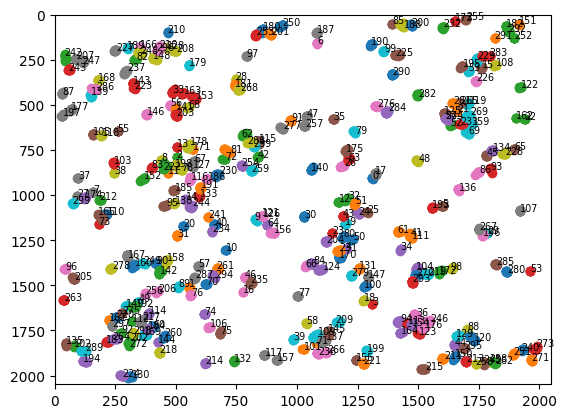

In [53]:
# dind=0
# df=analyze_signal(df_01222026, roi_ind=dind,metric='sum', plot_graph=True)
fig, ax = plt.subplots()
# for id in np.unique(novdf['ROI_ID'].values):

for id in range(300):
    roi_paths(novdf, roi_id=id, roi_radius=2)
# dind+=2

In [31]:
def ticks(img_df: pd.DataFrame, thresh: float=0.5):
    """
    Args: Dataframe containing extracted roi info to be analyzed.
    Outputs: Dataframe containing up and/or down tick frames for each unique roi. 
    """
    dfs=[]
    for roi_id in np.unique(img_df['ROI_ID'].values):
        vals=img_df.loc[img_df.ROI_ID==roi_id, 'sum'].values
        vals=vals/np.max(vals)
        yi=img_df.loc[img_df.ROI_ID==roi_id, 'y'].values[0]
        xi=img_df.loc[img_df.ROI_ID==roi_id, 'x'].values[0]
        frames=img_df.loc[img_df.ROI_ID==roi_id, 'frame'].values
        beg=frames[:4]
        end=frames[-4:]
        start_indices=np.where(beg<thresh)
        end_indices=np.where(end>thresh)
        # diffs=np.diff(vals)
        # indices=np.where(abs(diffs)>thresh)[0]
        if len(start_indices)>0:
            start_frame=beg[start_indices[0]]+1
        else:
            start_frame=None
        if len(end_indices)>0:
            div_frame=end[end_indices[-1]]+1
        else:
            div_frame=None
        
        # start_frame=None
        # div_frame=None
            # if diffs[ind]>0:
            #     start_frame=frames[ind]+1
            # else:
            #     div_frame=frames[ind] 

        metrics={
            "ROI_ID"      : [roi_id],
            "y"           : [yi],
            "x"           : [xi],
            "Start_Frame" : [start_frame],
            "Div_Frame"   : [div_frame]
        }

        roi_df=pd.DataFrame(metrics)
        dfs.append(roi_df)
    output_df=pd.concat(dfs, ignore_index=True)
    return output_df

In [40]:
tl=np.array([.1,.4,.6,.8,1])
# np.gradient(tl,.5)
dd=np.where(tl>.4)
tl[dd[0][-1]]

1.0

In [ ]:
# tt=ticks(novdf)
# # tf['Start Frame'][400:500]
# sframes=[s for s in tt['Start_Frame'].values if s is not None]
# dframes=[d for d in tt['Div_Frame'].values if d is not None]

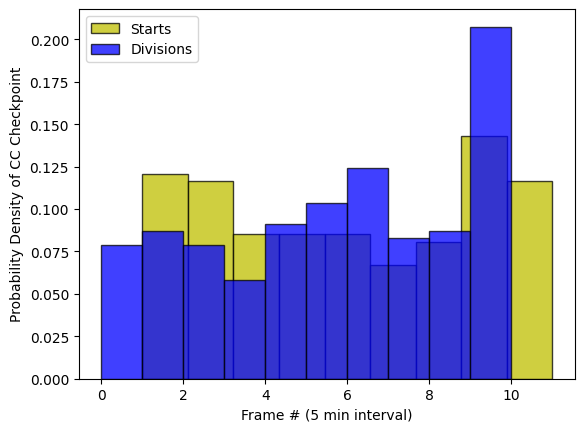

In [88]:
plt.figure()
plt.xlabel('Frame # (5 min interval)')
plt.ylabel('Probability Density of CC Checkpoint')
n0,b0,p0=plt.hist(sframes,bins='doane', alpha=0.75, edgecolor='black', density=True, color='y', label='Starts')
n1,b1,p1=plt.hist(dframes, bins='doane', alpha=0.75, edgecolor='black', density=True, color='b', label='Divisions')
plt.legend()

In [93]:
def roi_subplots(df: pd.DataFrame, num_rows: int, num_columns: int=2, metric: str='sum', normalize: bool=True, fit: bool=False, corr: bool=True, plot_fit: bool=False):
    """
    Args: Dataframe containing ROI_ID and pixel metric info, row & column dimensions, and optional argument to designate alternative metric.
    Outputs: Fitting parameters for exponential function. Figure consisting of subplots.
    """
    a_vals,b_vals,c_vals=[],[],[]
    plt.figure(figsize=(10,500))

    #Median parameters of exponential decay fits for 01292026_r2 data
    a_med,b_med,c_med=(0.7707111579952284,0.0620886804972008,0.1568112942306607)

    for roi_id in np.unique(df['ROI_ID'].values)[33:53]:
        roi_subset=df[df['ROI_ID'].values==roi_id].sort_values(by=['frame']) #apply roi mask and sort according to frame to deal with buffer frames out of order
        I_vals=roi_subset[metric].values
        frames=roi_subset['frame'].values
        if fit==True:
            #Fit an exponential curve and save fit parameters
            popt, pcov = curve_fit(exp_fnc, roi_subset['frame'].values, roi_subset[metric].values/max_px_val)
            a,b,c=popt
            a_vals.append(a)
            b_vals.append(b)
            c_vals.append(c)
        else:
            a,b,c=0,0,0
        if corr==True:
            I_vals=photobleach_correction(I_vals,frames,a_med,b_med,c_med)
        if normalize==True:
            max_px_val=np.max(I_vals)
        else:
            max_px_val=1
        I_vals=I_vals/max_px_val

        plt.subplot(num_rows,num_columns,roi_id+1) #locate subplot to use
        if plot_fit==True:
            plt.plot(frames, exp_fnc(roi_subset['frame'].values, *popt), 'k--',label='fit: a=%5.3f, b=%5.3f, c=%5.3f' % tuple(popt)) #plot exp fit
        plt.scatter(frames,I_vals,s=4,c='y',edgecolors='k', label='ROI_'+str(roi_id))
        plt.plot(frames,I_vals, label='Data')#plots desired metric as function of frame (proxy for time)
        
        # plt.ylabel('Pixel Intesity (AU)')
        # plt.xlabel('Frame (5 min intervals)')
        plt.ylim(0,1.25)
        plt.xlim(-1,np.max(df['frame'].values)+5)
        plt.legend(loc='best', fontsize='small')

    plt.show()
    return a_vals,b_vals,c_vals

def photobleach_correction(vals: np.ndarray,x: np.ndarray,a: float,b: float,c: float):
    """
    Args: Arrays of uncorrected pixel intensity value and frame indices; Three fitting paramters for exponential fit.
    Outputs: Array of corrected pixel intensity values.
    """
    output_ls=[vals[i]/exp_fnc(x[i],a,b,c) for i in range(len(vals))]
    return output_ls


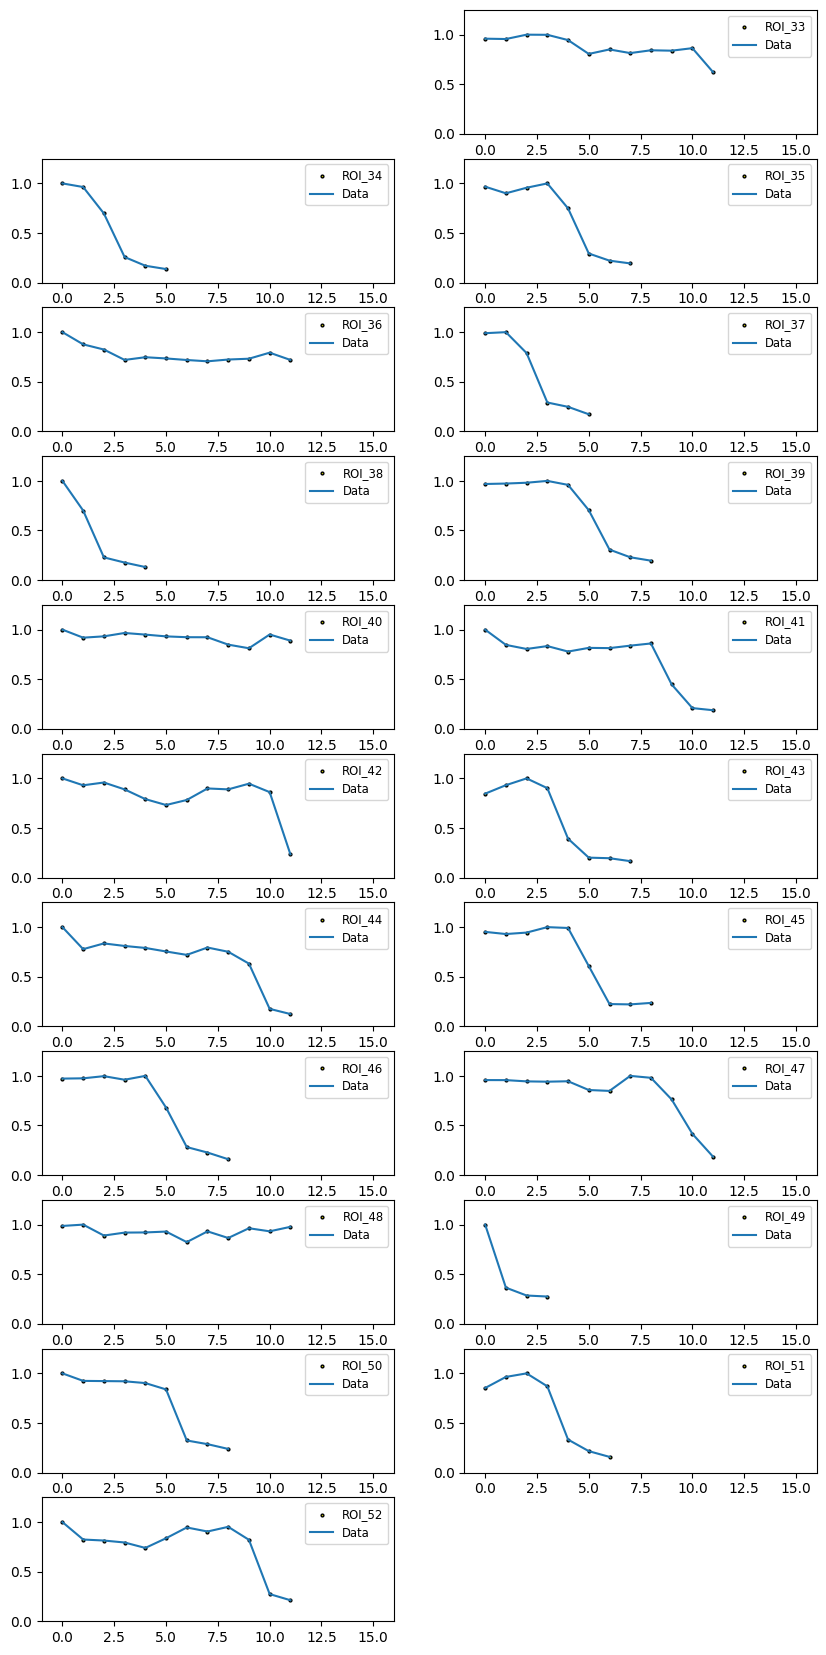

([], [], [])

In [94]:
roi_subplots(novdf, num_rows=int(len(np.unique(novdf['ROI_ID'].values))/2),fit=False,corr=False)
# roi_subplots(df_01222026, num_rows=int(len(np.unique(df_01222026['ROI_ID'].values))/2),fit=False,corr=True)

In [95]:
novdf.loc[novdf.ROI_ID==45]

,ROI_ID,frame,y,x,radius,sum,avg
204,45,0,784.0,1785.0,8.0,6800.312500,0.001621
562,45,1,782.0,1783.0,8.0,6645.199219,0.001584
843,45,2,782.0,1782.0,8.0,6749.265625,0.001609
1402,45,3,781.0,1783.0,8.0,7141.938477,0.001703
1771,45,4,781.0,1781.0,8.0,7081.733398,0.001688
2084,45,5,780.0,1782.0,8.0,4337.889648,0.001034
2404,45,6,780.0,1782.0,8.0,1601.598633,0.042997
2794,45,7,780.0,1782.0,8.0,1577.347900,0.042346
3134,45,8,780.0,1782.0,8.0,1684.706055,0.045228


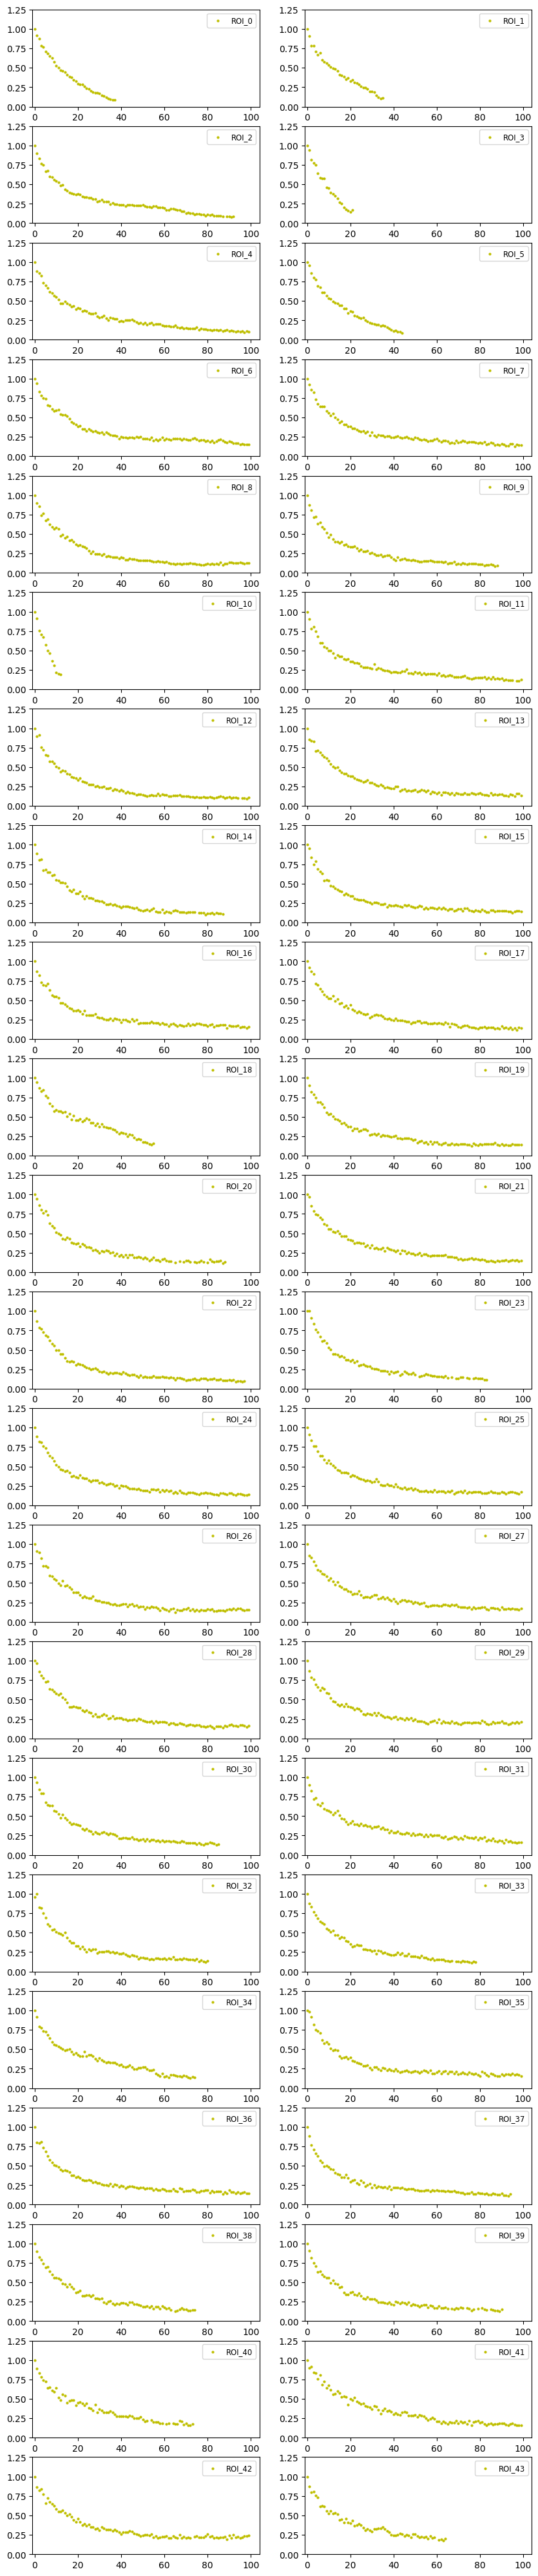

In [15]:
# wa,wb,wc=roi_subplots(df_01292026_r1, num_rows=int(len(np.unique(df_01292026_r1['ROI_ID'].values))/2),fit=True,corr=False)
xa,xb,xc=roi_subplots(df_01292026_r2, num_rows=int(len(np.unique(df_01292026_r2['ROI_ID'].values))/2), fit=True,corr=False)
# roi_subplots(janrun, num_rows=int(len(np.unique(janrun['ROI_ID'].values))/2))

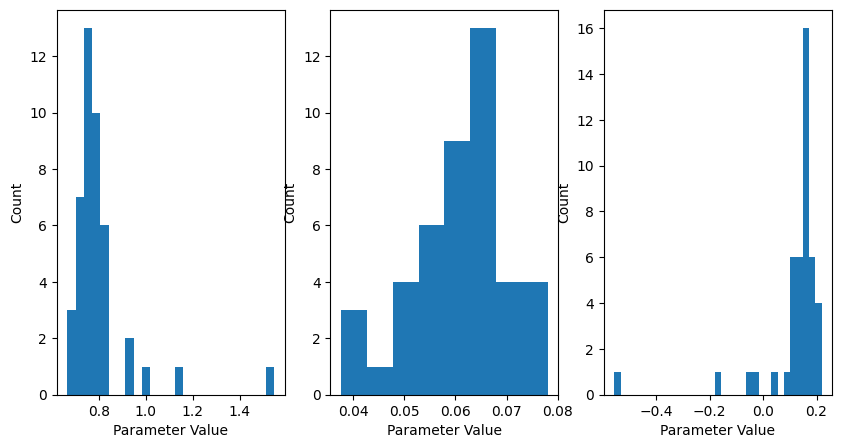

In [16]:
num_rows=1; num_columns=3
# r1_param_vals=[wa,wb,wc]
r2_param_vals=[xa,xb,xc]
plt.figure(figsize=(10,5))
for param_ind in np.arange(0,3):
    plt.subplot(num_rows,num_columns,param_ind+1) #locate subplot to use
    # plt.scatter()
    plt.hist(r2_param_vals[param_ind],bins='fd')
    plt.ylabel('Count')
    plt.xlabel('Parameter Value')
    # plt.legend(loc='best', fontsize='small')
    # plt.title('ROI '+str(roi_id))
 

In [22]:
fa,fb,fc=np.median(xa),np.median(xb),np.median(xc)

In [24]:
print(fa,fb,fc)

0.7707111579952284 0.0620886804972008 0.1568112942306607


In [108]:
# df_01292026.loc[df_01292026.ROI_ID==0].sort_values(by=['frame'])
# janrun.loc[janrun.ROI_ID==0].sort_values(by=['frame'])